# Preprocessing & Exploratory Data Analysis

This notebook covers:
1. Data Loading and Exploration
2. Data Cleaning & Missing Values
3. Exploratory Data Analysis (EDA)
4. Statistical Summary
5. Data Preparation for Feature Engineering

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 2. Load Data

In [3]:
# Define data path
data_path = Path('../data/raw/ojs-request-log/data-1777817575610.csv')

# Load the CSV file
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (6412, 11)

First few rows:


,id,timestamp,ip,method,path,query,body,headers,prediction,label,created_at
0,150,2026-05-02T09:51:11Z,43.252.106.82,GET,/index.php/index/$$$call$$$/page/page/css?name...,name=stylesheet,NaN,"{""Host"": ""extractor:8081"", ""Accept"": ""text/css...",Attack,Normal,2026-05-02 09:51:11.594042+00
1,2,2026-05-02T08:59:43Z,172.18.0.5,GET,/index.php/index/$$$call$$$/page/page/css?name...,name=stylesheet,NaN,"{""Host"": ""extractor:8081"", ""Accept"": ""text/css...",Attack,Normal,2026-05-02 08:59:43.898381+00
2,5,2026-05-02T09:00:55Z,43.252.106.82,GET,/,NaN,NaN,"{""Host"": ""extractor:8081"", ""Accept"": ""text/htm...",Normal,Normal,2026-05-02 09:00:55.251678+00
3,4,2026-05-02T09:00:33Z,43.252.106.82,GET,/,NaN,NaN,"{""Host"": ""extractor:8081"", ""Accept"": ""text/htm...",Normal,Normal,2026-05-02 09:00:33.169471+00
4,3,2026-05-02T09:00:27Z,43.252.106.82,GET,/,NaN,NaN,"{""Host"": ""extractor:8081"", ""Accept"": ""text/htm...",Normal,Normal,2026-05-02 09:00:27.026841+00


## 3. Data Overview

In [4]:
# Display column names and types
print("Column Information:")
print(df.info())
print(f"\nColumn Names: {df.columns.tolist()}")

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 6412 entries, 0 to 6411
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          6412 non-null   int64
 1   timestamp   6412 non-null   str  
 2   ip          6412 non-null   str  
 3   method      6412 non-null   str  
 4   path        6412 non-null   str  
 5   query       1214 non-null   str  
 6   body        3190 non-null   str  
 7   headers     6412 non-null   str  
 8   prediction  6412 non-null   str  
 9   label       6412 non-null   str  
 10  created_at  6412 non-null   str  
dtypes: int64(1), str(10)
memory usage: 551.2 KB
None

Column Names: ['id', 'timestamp', 'ip', 'method', 'path', 'query', 'body', 'headers', 'prediction', 'label', 'created_at']


## 4. Check for Missing Values

In [5]:
# Check missing values
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("✓ No missing values found!")

Missing Values Summary:
       Missing Count  Missing Percentage
query           5198           81.066750
body            3222           50.249532


## 5. Label Distribution Analysis

Label Distribution:
label
Normal    3287
Attack    3125
Name: count, dtype: int64

Label Percentage:
label
Normal    51.263256
Attack    48.736744
Name: proportion, dtype: float64


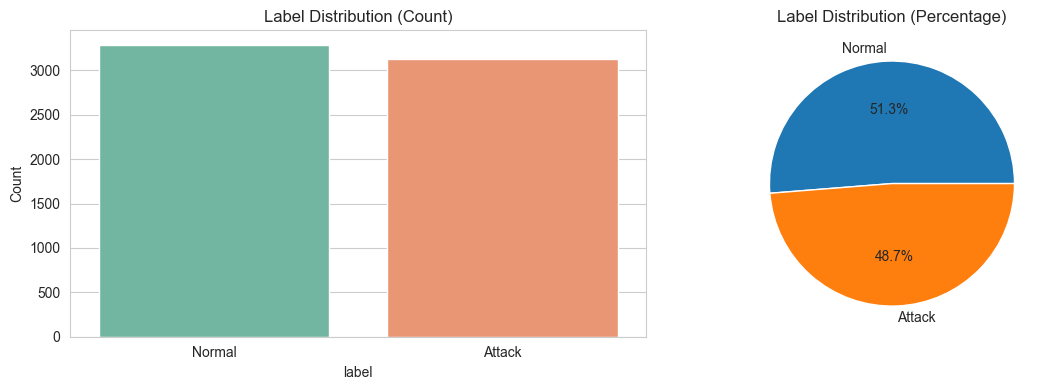

In [6]:
# Analyze the target variable
print("Label Distribution:")
label_counts = df['label'].value_counts()
print(label_counts)
print(f"\nLabel Percentage:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Label Distribution (Count)')
axes[0].set_ylabel('Count')

# Pie chart
df['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Label Distribution (Percentage)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 6. HTTP Method Analysis

HTTP Method Distribution:
method
GET        3421
POST       2987
HEAD          2
OPTIONS       2
Name: count, dtype: int64

HTTP Method vs Label:
label    Attack  Normal
method                 
GET         673    2748
HEAD          1       1
OPTIONS       0       2
POST       2451     536


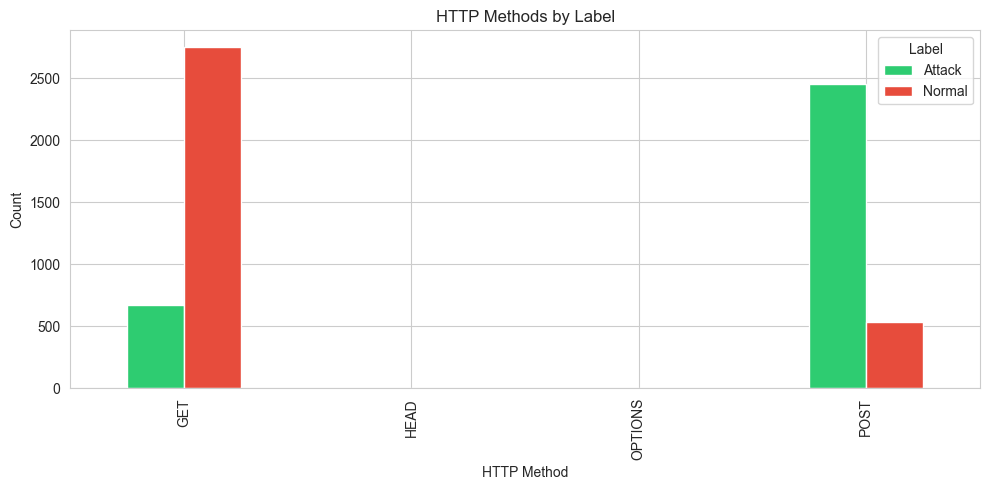

In [7]:
# Analyze HTTP methods
print("HTTP Method Distribution:")
print(df['method'].value_counts())

# Method vs Label
print("\nHTTP Method vs Label:")
print(pd.crosstab(df['method'], df['label']))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
pd.crosstab(df['method'], df['label']).plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('HTTP Methods by Label')
ax.set_xlabel('HTTP Method')
ax.set_ylabel('Count')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

## 7. Path Length Analysis

Path Length Statistics:
count    6412.000000
mean       38.879913
std        23.972634
min         1.000000
25%        31.000000
50%        32.000000
75%        49.000000
max       404.000000
Name: path_length, dtype: float64


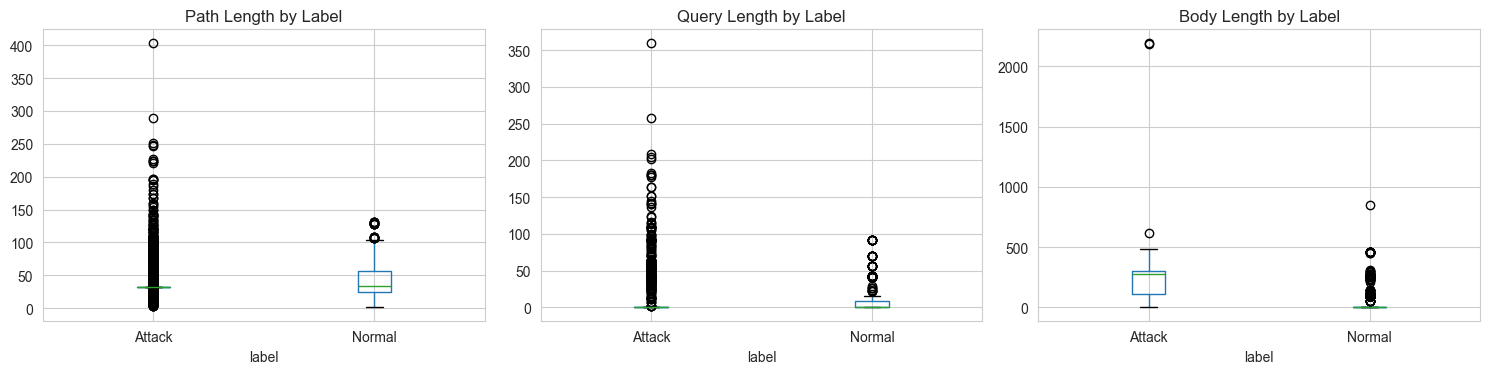

In [8]:
# Analyze request paths
df['path_length'] = df['path'].str.len()
df['query_length'] = df['query'].fillna('').str.len()
df['body_length'] = df['body'].fillna('').str.len()

print("Path Length Statistics:")
print(df['path_length'].describe())

# Visualize path lengths by label
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.boxplot(column='path_length', by='label', ax=axes[0])
axes[0].set_title('Path Length by Label')

df.boxplot(column='query_length', by='label', ax=axes[1])
axes[1].set_title('Query Length by Label')

df.boxplot(column='body_length', by='label', ax=axes[2])
axes[2].set_title('Body Length by Label')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 8. Timestamp Analysis

Timestamp Range:
From: 2026-05-02 08:59:43+00:00
To: 2026-05-03 14:06:11+00:00
Duration: 1 days 05:06:28


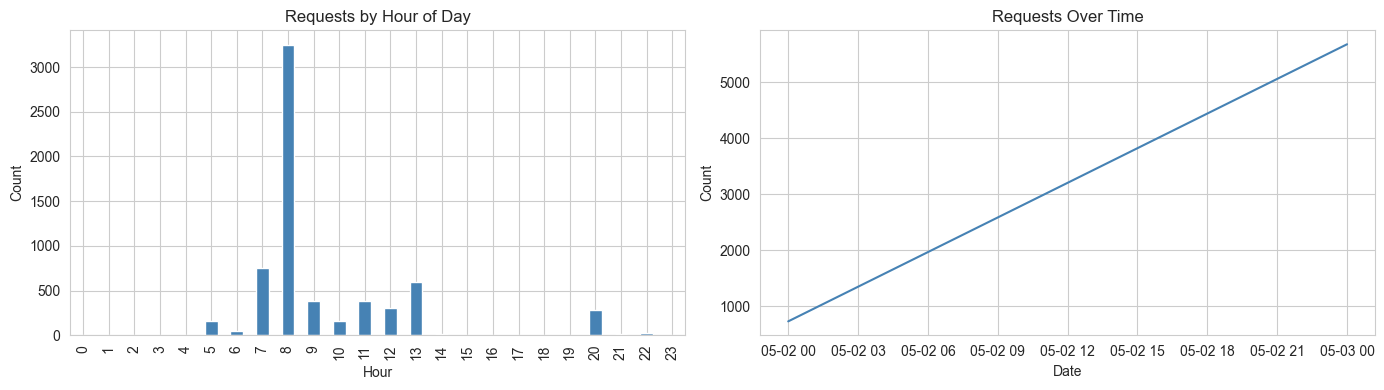

In [9]:
# Convert timestamp columns to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['created_at'] = pd.to_datetime(df['created_at'])

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['date'] = df['timestamp'].dt.date

print("Timestamp Range:")
print(f"From: {df['timestamp'].min()}")
print(f"To: {df['timestamp'].max()}")
print(f"Duration: {df['timestamp'].max() - df['timestamp'].min()}")

# Visualize requests by hour
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('hour').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Requests by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

df.groupby('date').size().plot(kind='line', ax=axes[1], color='steelblue')
axes[1].set_title('Requests Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 9. IP Analysis

Top 10 Source IPs:
ip
103.79.247.85                            4394
43.252.106.82                             665
2404:c0:9c27:4ab3:e5cd:cdc9:609f:98f5     373
182.4.133.37                              269
36.92.231.74                              110
150.129.59.5                              108
172.18.0.5                                 57
165.22.152.67                              45
107.173.61.109                             45
216.57.110.81                              44
Name: count, dtype: int64

Attack Distribution by Top IPs:
label                                  Attack  Normal
ip                                                   
103.79.247.85                            2869    1525
107.173.61.109                             45       0
150.129.59.5                                0     108
165.22.152.67                              45       0
172.18.0.5                                 43      14
182.4.133.37                                0     269
216.57.110.81              

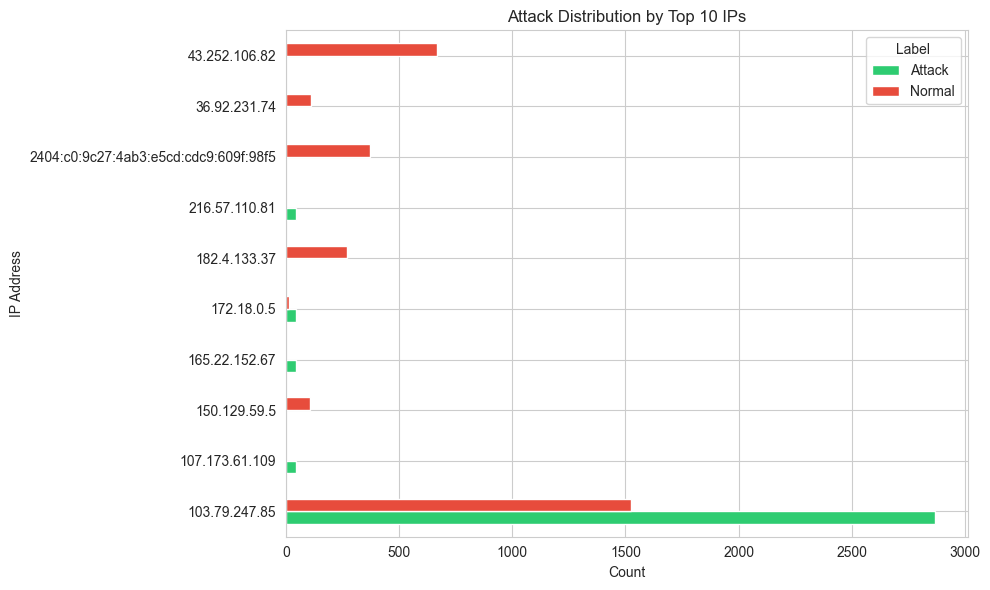

In [10]:
# Analyze IPs
print("Top 10 Source IPs:")
print(df['ip'].value_counts().head(10))

print("\nAttack Distribution by Top IPs:")
top_ips = df['ip'].value_counts().head(10).index
attack_by_ip = df[df['ip'].isin(top_ips)].groupby('ip')['label'].value_counts().unstack(fill_value=0)
print(attack_by_ip)

# Visualize
attack_by_ip.plot(kind='barh', figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Attack Distribution by Top 10 IPs')
plt.xlabel('Count')
plt.ylabel('IP Address')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

## 10. Header Analysis

Header Count Statistics:
count    6412.000000
mean       26.004835
std         6.230993
min         9.000000
25%        25.000000
50%        28.000000
75%        31.000000
max        33.000000
Name: header_count, dtype: float64


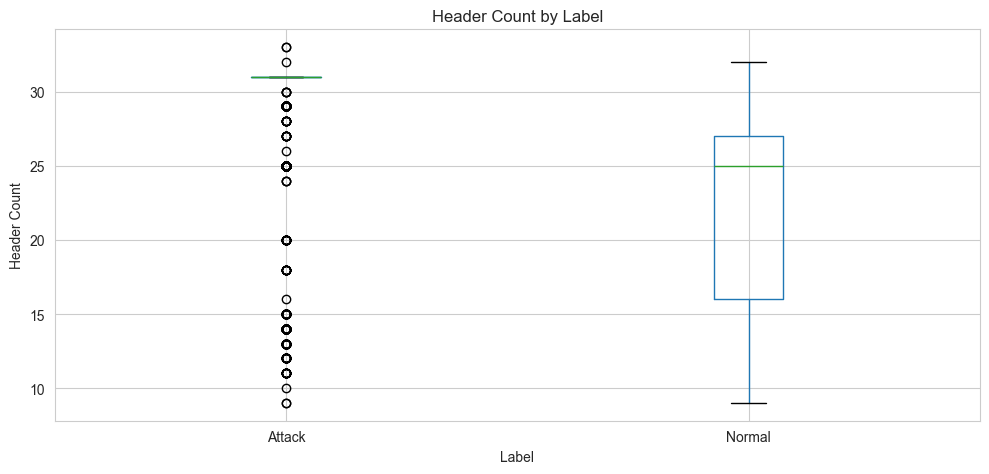

In [11]:
# Parse headers
def parse_headers(header_str):
    if pd.isna(header_str):
        return {}
    try:
        return json.loads(header_str)
    except:
        return {}

# Extract header information
df['header_count'] = df['headers'].apply(lambda x: len(parse_headers(x)))

print("Header Count Statistics:")
print(df['header_count'].describe())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='header_count', by='label', ax=ax)
ax.set_title('Header Count by Label')
ax.set_xlabel('Label')
ax.set_ylabel('Header Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 11. Data Cleaning & Preparation

In [12]:
# Create a copy for processing
df_processed = df.copy()

# Fill missing values
df_processed['query'] = df_processed['query'].fillna('')
df_processed['body'] = df_processed['body'].fillna('')
df_processed['headers'] = df_processed['headers'].fillna('{}')

# Display cleaned data info
print("Processed Data Info:")
print(f"Shape: {df_processed.shape}")
print(f"\nData types:")
print(df_processed.dtypes)

# Check for duplicates
print(f"\nDuplicate rows: {df_processed.duplicated().sum()}")

Processed Data Info:
Shape: (6412, 18)

Data types:
id                            int64
timestamp       datetime64[us, UTC]
ip                              str
method                          str
path                            str
query                           str
body                            str
headers                         str
prediction                      str
label                           str
created_at      datetime64[us, UTC]
path_length                   int64
query_length                  int64
body_length                   int64
hour                          int32
day_of_week                   int32
date                         object
header_count                  int64
dtype: object

Duplicate rows: 0


## 12. Save Processed Data

In [13]:
# Save processed data
output_path = Path('../data/processed/v0.1.1/eda_cleaned_data.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save without index
df_processed.to_csv(output_path, index=False)

print(f"✓ Processed data saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

✓ Processed data saved to: ..\data\processed\eda_cleaned_data.csv
File size: 9.56 MB


## Summary

- **Total Records**: {df.shape[0]}
- **Total Features**: {df.shape[1]}
- **Attack Rate**: {(df['label'] == 'Attack').sum() / len(df) * 100:.2f}%
- **Data Quality**: No missing values in critical columns
- **Time Range**: {df['timestamp'].min()} to {df['timestamp'].max()}